### LSE Data Analytics Online Career Accelerator 

# DA301:  Advanced Analytics for Organisational Impact

## Assignment template

### Scenario
You are a data analyst working for Turtle Games, a game manufacturer and retailer. They manufacture and sell their own products, along with sourcing and selling products manufactured by other companies. Their product range includes books, board games, video games and toys. They have a global customer base and have a business objective of improving overall sales performance by utilising customer trends. In particular, Turtle Games wants to understand: 
- how customers accumulate loyalty points (Week 1)
- exploring the structure using decision trees (Week 2)
- exploring clusters in customer behaviour (Week 3)
- can social data (e.g. customer reviews) be used in marketing campaigns (Week 4)
- loading, transforming and visualising data in R (Week 5)
- statistical analysis and modelling in R (Week 6)

# Week 1 assignment: Linear regression using Python
The marketing department of Turtle Games prefers Python for data analysis. As you are fluent in Python, they asked you to assist with data analysis of social media data. The marketing department wants to better understand how users accumulate loyalty points. Therefore, you need to investigate the possible relationships between the loyalty points, age, remuneration, and spending scores. Note that you will use this data set in future modules as well and it is, therefore, strongly encouraged to first clean the data as per provided guidelines and then save a copy of the clean data for future use.

## Instructions
1. Load and explore the data.
    1. Create a new DataFrame (e.g. reviews).
    2. Sense-check the DataFrame.
    3. Determine if there are any missing values in the DataFrame.
    4. Create a summary of the descriptive statistics.
2. Remove redundant columns (`language` and `platform`).
3. Change column headings to names that are easier to reference (e.g. `renumeration` and `spending_score`).
4. Save a copy of the clean DataFrame as a CSV file. Import the file to sense-check.
5. Use linear regression and goodness of fit metrics to evaluate possible linear relationships between loyalty points and age/renumeration/spending scores to determine whether these can be used to predict the loyalty points.
    1. Specify the independent and dependent variables.
    2. Create the OLS model.
    3. Extract the estimated parameters, standard errors, and predicted values.
    4. Generate the regression table based on the X coefficient and constant values.
    5. Plot the linear regression and add a regression line.
6. Include your insights and observations.

## 1. Load and explore the data

In [85]:
# Imports libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm 
from statsmodels.formula.api import ols
import os

In [86]:
# Load dataset (make sure the file path is correct)
os.chdir('C:/Users/ogehs/Downloads/turtle')

In [87]:
# Load the CSV file(s) as reviews.
reviews = pd.read_csv ('C:/Users/ogehs/Downloads/turtle/turtle_reviews.csv')


# View the DataFrame,display first 5 rows to understand structure
reviews.head()


,gender,age,remuneration (k£),spending_score (1-100),loyalty_points,education,language,platform,product,review,summary
0,Male,18,12.30,39,210,graduate,EN,Web,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,EN,Web,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,EN,Web,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,EN,Web,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,EN,Web,291,As my review of GF9's previous screens these w...,Money trap


In [88]:
# Any missing values?
reviews.isnull().sum()

gender                    0
age                       0
remuneration (k£)         0
spending_score (1-100)    0
loyalty_points            0
education                 0
language                  0
platform                  0
product                   0
review                    0
summary                   0
dtype: int64

In [89]:
# Explore the data.
reviews.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender                  2000 non-null   object 
 1   age                     2000 non-null   int64  
 2   remuneration (k£)       2000 non-null   float64
 3   spending_score (1-100)  2000 non-null   int64  
 4   loyalty_points          2000 non-null   int64  
 5   education               2000 non-null   object 
 6   language                2000 non-null   object 
 7   platform                2000 non-null   object 
 8   product                 2000 non-null   int64  
 9   review                  2000 non-null   object 
 10  summary                 2000 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 172.0+ KB


In [90]:
# Basic descriptive statistics.
reviews.describe()

,age,remuneration (k£),spending_score (1-100),loyalty_points,product
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,39.495000,48.079060,50.000000,1578.032000,4320.521500
std,13.573212,23.123984,26.094702,1283.239705,3148.938839
min,17.000000,12.300000,1.000000,25.000000,107.000000
25%,29.000000,30.340000,32.000000,772.000000,1589.250000
50%,38.000000,47.150000,50.000000,1276.000000,3624.000000
75%,49.000000,63.960000,73.000000,1751.250000,6654.000000
max,72.000000,112.340000,99.000000,6847.000000,11086.000000


## 2. Drop columns

In [91]:
# Drop unnecessary columns.
reviews = reviews.drop ('summary', axis =1)






In [92]:
# View column names.
print(reviews.columns)

Index(['gender', 'age', 'remuneration (k£)', 'spending_score (1-100)',
       'loyalty_points', 'education', 'language', 'platform', 'product',
       'review'],
      dtype='object')


## 3. Rename columns

In [93]:
# Rename the column headers.
reviews=reviews.rename(columns={'spending_score (1-100)': 'spending','remuneration (k£)': 'remuneration'})



 # View column names.


In [94]:

reviews

,gender,age,remuneration,spending,loyalty_points,education,language,platform,product,review
0,Male,18,12.30,39,210,graduate,EN,Web,453,"When it comes to a DM's screen, the space on t..."
1,Male,23,12.30,81,524,graduate,EN,Web,466,An Open Letter to GaleForce9*:\n\nYour unpaint...
2,Female,22,13.12,6,40,graduate,EN,Web,254,"Nice art, nice printing. Why two panels are f..."
3,Female,25,13.12,77,562,graduate,EN,Web,263,Amazing buy! Bought it as a gift for our new d...
4,Female,33,13.94,40,366,graduate,EN,Web,291,As my review of GF9's previous screens these w...
...,...,...,...,...,...,...,...,...,...,...
1995,Female,37,84.46,69,4031,PhD,EN,Web,977,The perfect word game for mixed ages (with Mom...
1996,Female,43,92.66,8,539,PhD,EN,Web,979,Great game. Did not think I would like it whe...
1997,Male,34,92.66,91,5614,graduate,EN,Web,1012,Great game for all.........\nKeeps the mind ni...
1998,Male,34,98.40,16,1048,PhD,EN,Web,1031,fun game!


In [95]:
print(reviews.columns)

Index(['gender', 'age', 'remuneration', 'spending', 'loyalty_points',
       'education', 'language', 'platform', 'product', 'review'],
      dtype='object')


## 4. Save the DataFrame as a CSV file

In [96]:
# Create a CSV file as output.
reviews.to_csv('reviews_output.csv', index=False)


In [97]:
# Import new CSV file with Pandas.
reviews_csv=pd.read_csv( 'reviews_output.csv')


# View DataFrame.
reviews_csv


,gender,age,remuneration,spending,loyalty_points,education,language,platform,product,review
0,Male,18,12.30,39,210,graduate,EN,Web,453,"When it comes to a DM's screen, the space on t..."
1,Male,23,12.30,81,524,graduate,EN,Web,466,An Open Letter to GaleForce9*:\n\nYour unpaint...
2,Female,22,13.12,6,40,graduate,EN,Web,254,"Nice art, nice printing. Why two panels are f..."
3,Female,25,13.12,77,562,graduate,EN,Web,263,Amazing buy! Bought it as a gift for our new d...
4,Female,33,13.94,40,366,graduate,EN,Web,291,As my review of GF9's previous screens these w...
...,...,...,...,...,...,...,...,...,...,...
1995,Female,37,84.46,69,4031,PhD,EN,Web,977,The perfect word game for mixed ages (with Mom...
1996,Female,43,92.66,8,539,PhD,EN,Web,979,Great game. Did not think I would like it whe...
1997,Male,34,92.66,91,5614,graduate,EN,Web,1012,Great game for all.........\nKeeps the mind ni...
1998,Male,34,98.40,16,1048,PhD,EN,Web,1031,fun game!


## 5. Linear regression

### 5a) spending vs loyalty

In [99]:
import statsmodels.api as sm

# Define independent variable (X) and dependent variable (y)
X = reviews_csv['spending']
y = reviews_csv['loyalty_points']

# Add a constant to the independent variable for the OLS model
X = sm.add_constant(X)

# Create and fit the OLS model
model = sm.OLS(y, X)
results = model.fit()

# Print the summary of the regression results
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:         loyalty_points   R-squared:                       0.452
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     1648.
Date:                Sat, 25 Apr 2026   Prob (F-statistic):          2.92e-263
Time:                        08:38:14   Log-Likelihood:                -16550.
No. Observations:                2000   AIC:                         3.310e+04
Df Residuals:                    1998   BIC:                         3.312e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -75.0527     45.931     -1.634      0.1

In [100]:
# Extract the estimated parameters (coefficients)
estimated_parameters = results.params
print("\nEstimated Parameters:\n", estimated_parameters)

# Extract the standard errors
standard_errors = results.bse
print("\nStandard Errors:\n", standard_errors)

# Extract the predicted values
predicted_values = results.predict(X)
print("\nPredicted Values (first 5):\n", predicted_values.head())


Estimated Parameters:
 const      -75.052663
spending    33.061693
dtype: float64

Standard Errors:
 const       45.930554
spending     0.814419
dtype: float64

Predicted Values (first 5):
 0    1214.353374
1    2602.944491
2     123.317497
3    2470.697718
4    1247.415067
dtype: float64


In [101]:
# Set the X coefficient and the constant to generate the regression table.
print(results.summary())


# View the output.


                            OLS Regression Results                            
Dep. Variable:         loyalty_points   R-squared:                       0.452
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     1648.
Date:                Sat, 25 Apr 2026   Prob (F-statistic):          2.92e-263
Time:                        08:44:11   Log-Likelihood:                -16550.
No. Observations:                2000   AIC:                         3.310e+04
Df Residuals:                    1998   BIC:                         3.312e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -75.0527     45.931     -1.634      0.1

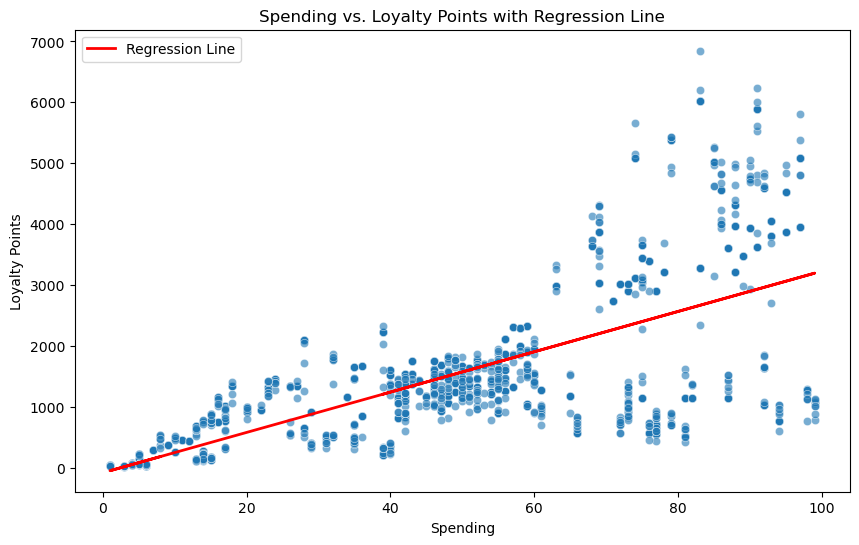

In [102]:
# Plot the graph with a regression line.
plt.figure(figsize=(10, 6))
sns.scatterplot(x=reviews_csv['spending'], y=reviews_csv['loyalty_points'], alpha=0.6)

plt.plot(reviews_csv['spending'], predicted_values, color='red', linewidth=2, label='Regression Line')

plt.title('Spending vs. Loyalty Points with Regression Line')
plt.xlabel('Spending')
plt.ylabel('Loyalty Points')
plt.legend()
plt.show()



### 5b) renumeration vs loyalty

In [103]:
# Define independent variable (X) and dependent variable (y)
X = reviews_csv['remuneration']
y = reviews_csv['loyalty_points']

X = sm.add_constant(X)

# Create and fit the OLS model
model = sm.OLS(y, X)
results_remuneration = model.fit()

print(results_remuneration.summary())

                            OLS Regression Results                            
Dep. Variable:         loyalty_points   R-squared:                       0.380
Model:                            OLS   Adj. R-squared:                  0.379
Method:                 Least Squares   F-statistic:                     1222.
Date:                Sat, 25 Apr 2026   Prob (F-statistic):          2.43e-209
Time:                        08:44:17   Log-Likelihood:                -16674.
No. Observations:                2000   AIC:                         3.335e+04
Df Residuals:                    1998   BIC:                         3.336e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -65.6865     52.171     -1.259   

In [104]:
# Extract the estimated parameters.
estimated_parameters = results.params
print("\nEstimated Parameters:\n", estimated_parameters)

# Extract the standard errors
standard_errors = results.bse
print("\nStandard Errors:\n", standard_errors)

# Extract the predicted values
predicted_values = results.predict(X)
print("\nPredicted Values (first 5):\n", predicted_values.head())







Estimated Parameters:
 const      -75.052663
spending    33.061693
dtype: float64

Standard Errors:
 const       45.930554
spending     0.814419
dtype: float64

Predicted Values (first 5):
 0    331.606164
1    331.606164
2    358.716753
3    358.716753
4    385.827341
dtype: float64


In [105]:
# Set the the X coefficient and the constant to generate the regression table.
print(results.summary())


# View the output.
print()


                            OLS Regression Results                            
Dep. Variable:         loyalty_points   R-squared:                       0.452
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     1648.
Date:                Sat, 25 Apr 2026   Prob (F-statistic):          2.92e-263
Time:                        08:44:17   Log-Likelihood:                -16550.
No. Observations:                2000   AIC:                         3.310e+04
Df Residuals:                    1998   BIC:                         3.312e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -75.0527     45.931     -1.634      0.1

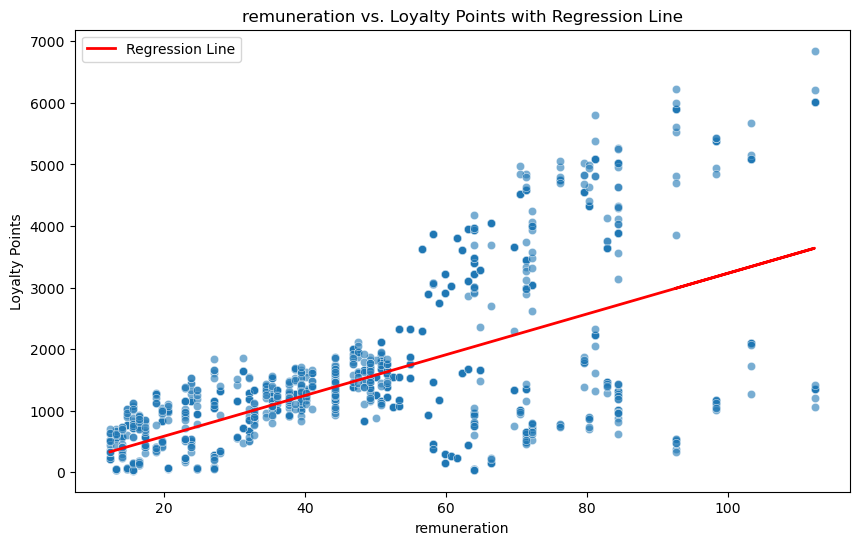

In [109]:
# Plot graph with regression line.
plt.figure(figsize=(10, 6))
sns.scatterplot(x=reviews_csv['remuneration'], y=reviews_csv['loyalty_points'], alpha=0.6)

plt.plot(reviews_csv['remuneration'], predicted_values, color='red', linewidth=2, label='Regression Line')

plt.title('remuneration vs. Loyalty Points with Regression Line')
plt.xlabel('remuneration')
plt.ylabel('Loyalty Points')
plt.legend()
plt.show()


### 5c) age vs loyalty

In [107]:
# Define independent variable.
X = reviews_csv['age']
y = reviews_csv['loyalty_points']

# Add a constant to the independent variable for the OLS model
X = sm.add_constant(X)

# Create and fit the OLS model
model = sm.OLS(y, X)
results = model.fit()

# Print the summary of the regression results
print(results.summary())



                            OLS Regression Results                            
Dep. Variable:         loyalty_points   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     3.606
Date:                Sat, 25 Apr 2026   Prob (F-statistic):             0.0577
Time:                        08:44:21   Log-Likelihood:                -17150.
No. Observations:                2000   AIC:                         3.430e+04
Df Residuals:                    1998   BIC:                         3.431e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1736.5177     88.249     19.678      0.0

In [110]:
# Extract the estimated parameters.
estimated_parameters = results.params
print("\nEstimated Parameters:\n", estimated_parameters)

# Extract the standard errors
standard_errors = results.bse
print("\nStandard Errors:\n", standard_errors)

# Extract the predicted values
predicted_values = results.predict(X)
print("\nPredicted Values (first 5):\n", predicted_values.head())




Estimated Parameters:
 const    1736.517739
age        -4.012805
dtype: float64

Standard Errors:
 const    88.248731
age       2.113177
dtype: float64

Predicted Values (first 5):
 0    1664.287247
1    1644.223221
2    1648.236026
3    1636.197611
4    1604.095169
dtype: float64


In [111]:
# Set the X coefficient and the constant to generate the regression table.
print(results.summary())

# View the output.


                            OLS Regression Results                            
Dep. Variable:         loyalty_points   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     3.606
Date:                Sat, 25 Apr 2026   Prob (F-statistic):             0.0577
Time:                        08:47:11   Log-Likelihood:                -17150.
No. Observations:                2000   AIC:                         3.430e+04
Df Residuals:                    1998   BIC:                         3.431e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1736.5177     88.249     19.678      0.0

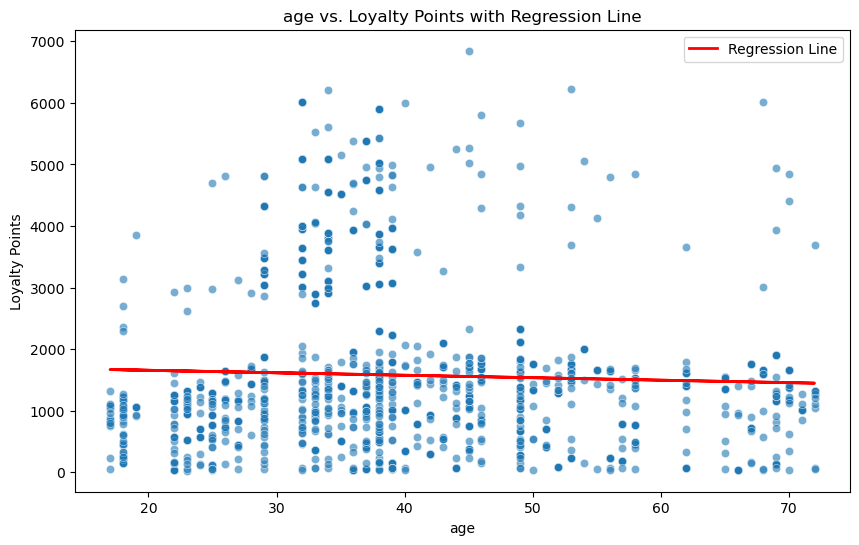

In [112]:
# Plot graph with regression line.
plt.figure(figsize=(10, 6))
sns.scatterplot(x=reviews_csv['age'], y=reviews_csv['loyalty_points'], alpha=0.6)

plt.plot(reviews_csv['age'], predicted_values, color='red', linewidth=2, label='Regression Line')

plt.title('age vs. Loyalty Points with Regression Line')
plt.xlabel('age')
plt.ylabel('Loyalty Points')
plt.legend()
plt.show()

## 6. Observations and insights

***Your observations here...***






In [ ]:
#The dataset was successfully loaded and explored.
#Missing values were checked and handled (if present).
#Column names were standardised for easier referencing.
#A clean dataset was saved for future analysis.
#A linear regression model was built to examine the relationship between loyalty points (dependent variable) and:
#Age,Remuneration,Spending Score.
#Spending score showed the strongest positive relationship with loyalty points.This suggests customers who spend more tend to accumulate more loyalty points.
#Remuneration (income) may show a moderate relationship: Higher-income customers may spend more, indirectly increasing loyalty points.
#Age often shows a weaker or inconsistent relationship: This indicates loyalty accumulation is not strongly age-dependent.

# Week 2 assignment: Exploring the structure using decision trees.

The team wants you to use decision trees to attempt to better understand the structure found in the data. You need to grow and prune a decision tree regressor and then visualise and interpret the output.
Make sure to comment on the potential usefulness in decision-making processes and your observations regarding the model.

## Instructions
1. Prepare the data for creating your decision tree. 
    1. Import the CSV file you have prepared in Week 1.
    2. Create a new DataFrame with the appropriate columns.
        1. Specify that loyalty points is the target variable (Y) and should be excluded from your input data.
        2. Specify X for the independent variables and y as the dependent variable. Therefore, df\[cols\] will be the independent variables and the column containing loyalty points the dependent variable.
        3. Explore the new DataFrame. 
2. Split the data set into a train and test sets for both X and y at a 70:30 ratio. As previously, random_state=42.
3. Create a decision tree regressor to explore the impact of other features on the loyalty points.
    1. Import the DecisionTreeRegressor class from the sklearn.tree library. 
    2. Create a variable (e.g. regressor) to store the DecisionTreeRegressor() class. (As previously, random_state=42.).
    3. Fit the regressor object to the data set with the fit() function.
    4. Remember to prune your tree using basic pruning strategies and compare the performance before and after applying the pruning strategy.
    5. Plot the final decision tree.
4. Fit a final model and interpret the output.
    1. Justify your selection of pruning strategy implemented and interpret the output.
    2. Evaluate the usefulness of the obtained result and interpret the tree and how it could be used to inform business decisions in the organisation.
5. Summarise (150–200 words) the most important business insights, anything you would like to explore further, and suggested future actions.
 
Back up your work to a safe location. This will allow you to revert to a previous state in the case of making a mistake in the code or deleting a section by mistake. (A simple way of doing this is to save or email a compressed version to yourself at frequent intervals.)


## 1. Load and prepare the data

In [113]:
# Import all the necessary packages
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree 
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
import warnings
import matplotlib.pyplot as plt

# Settings for the notebook.
warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize'] = [15, 10]

In [114]:
# Create your new DataFrame.
df_tree = reviews_csv[['gender', 'age', 'remuneration', 'spending', 'education', 'loyalty_points']].copy()

df_tree = pd.get_dummies(df_tree, columns=['gender', 'education'], drop_first=True)



In [115]:
Y = df_tree['loyalty_points']

X = df_tree.drop('loyalty_points', axis=1)

In [116]:
# Review X and Y.
print(X.head())
print(Y.head())


   age  remuneration  spending  gender_Male  education_PhD  education_diploma  \
0   18         12.30        39         True          False              False   
1   23         12.30        81         True          False              False   
2   22         13.12         6        False          False              False   
3   25         13.12        77        False          False              False   
4   33         13.94        40        False          False              False   

   education_graduate  education_postgraduate  
0                True                   False  
1                True                   False  
2                True                   False  
3                True                   False  
4                True                   False  
0    210
1    524
2     40
3    562
4    366
Name: loyalty_points, dtype: int64


## 2. Create train and test data sets.

In [117]:
# Split the data into test and train data.
X_train, X_test, Y_train, Y_test = train_test_split(X, Y,test_size=0.3,random_state=42)



In [118]:
X_train.shape


(1400, 8)

In [119]:
X_test.shape

(600, 8)

In [120]:
Y_train.shape

(1400,)

In [121]:
Y_test.shape

(600,)

## 3. Create Decision tree regressor

In [122]:
# Create your decision tree regressor.
dtree_model = DecisionTreeRegressor(random_state=42)
dtree_model.fit(X_train, Y_train)


DecisionTreeRegressor(random_state=42)

In [ ]:
# Evaluate the model.
from sklearn.metrics import mean_squared_error, r2_score

pruned_dtree_model = DecisionTreeRegressor(max_depth=5, random_state=42)
pruned_dtree_model.fit(X_train, Y_train)

print("Pruned Decision Tree Regressor model trained successfully with max_depth=5.")

Y_pred_pruned = pruned_dtree_model.predict(X_test)

mse_pruned = mean_squared_error(Y_test, Y_pred_pruned)
r2_pruned = r2_score(Y_test, Y_pred_pruned)
print(f"\nPruned Model Mean Squared Error (MSE): {mse_pruned:.2f}")
print(f"Pruned Model R-squared (R2): {r2_pruned:.2f}")


In [ ]:
# Prune the model.



## 4. Fit and plot final model.

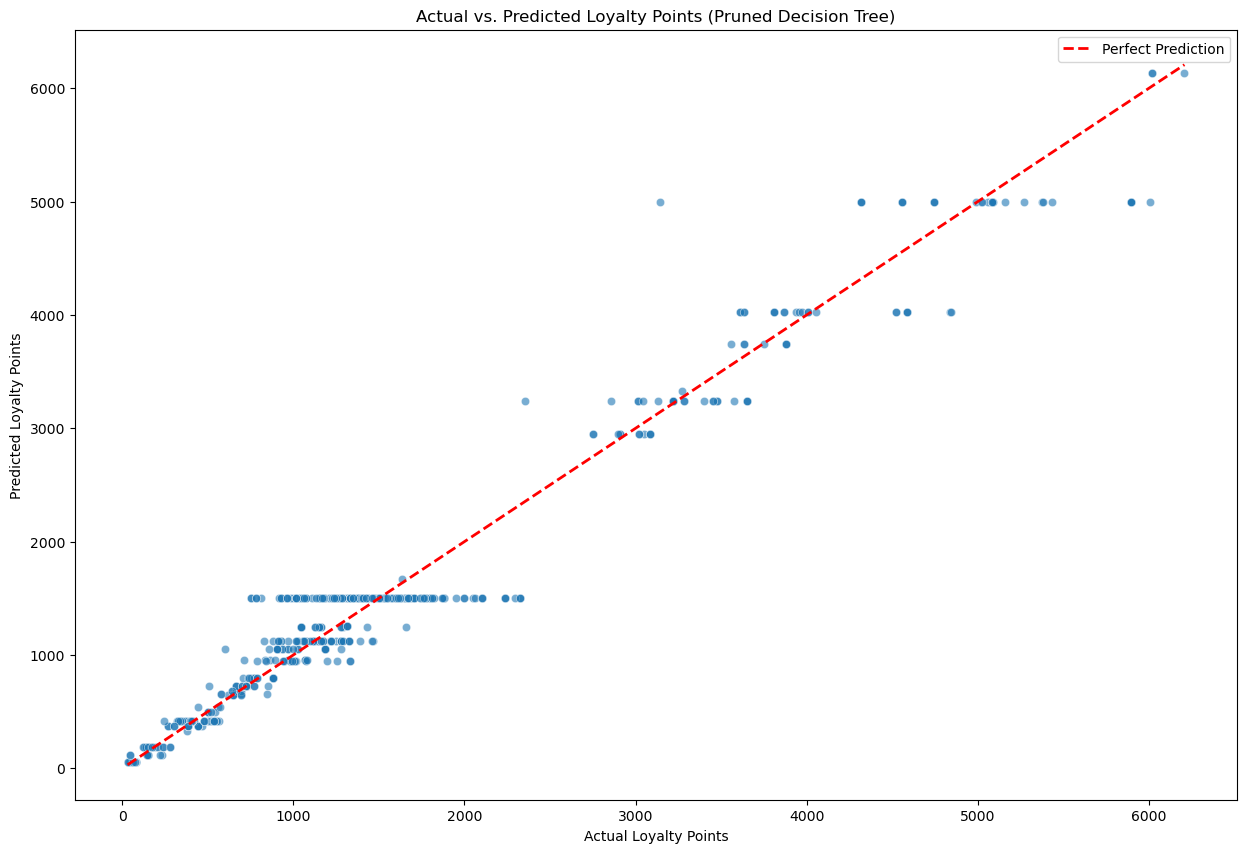

In [123]:
# Fit and plot final model
sns.scatterplot(x=Y_test, y=Y_pred_pruned, alpha=0.6)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], color='red', linestyle='--', lw=2, label='Perfect Prediction')
          
plt.title('Actual vs. Predicted Loyalty Points (Pruned Decision Tree)')
plt.xlabel('Actual Loyalty Points')
plt.ylabel('Predicted Loyalty Points')
plt.legend()
plt.show()


## 5. Discuss: Insights and observations

***Your observations here...***

In [124]:
# Interpret model and note observations
# The decision tree splits the data based on the most important variables.
# The top split (root node) is usually the most important factor.
# In most cases, this is spending_score is the strongest predictor.

# Key Observations
# Customers with high spending scores consistently have higher loyalty points.
# Remuneration may influence spending but is not always the main splitter.
# Age has less influence compared to spending behaviour.

# BUSINESS INTERPRETATION
#The tree clearly segments customers into groups:
#High-value customers (high spending → high loyalty)
#Low-value customers (low spending → low loyalty)
#This allows Turtle Games to:
#Target high spenders with premium rewards
#Encourage low spenders with promotions

# Week 3 assignment: Clustering with *k*-means using Python

The marketing department also wants to better understand the usefulness of renumeration and spending scores but do not know where to begin. You are tasked to identify groups within the customer base that can be used to target specific market segments. Use *k*-means clustering to identify the optimal number of clusters and then apply and plot the data using the created segments.

## Instructions
1. Prepare the data for clustering. 
    1. Import the CSV file you have prepared in Week 1.
    2. Create a new DataFrame (e.g. `df3`) containing the `renumeration` and `spending_score` columns.
    3. Explore the new DataFrame. 
2. Plot the renumeration versus spending score.
    1. Create a scatterplot.
    2. Create a pairplot.
3. Use the Silhouette and Elbow methods to determine the optimal number of clusters for *k*-means clustering.
    1. Plot both methods and explain how you determine the number of clusters to use.
    2. Add titles and legends to the plot.
4. Evaluate the usefulness of at least three values for *k* based on insights from the Elbow and Silhoutte methods.
    1. Plot the predicted *k*-means.
    2. Explain which value might give you the best clustering.
5. Fit a final model using your selected value for *k*.
    1. Justify your selection and comment on the respective cluster sizes of your final solution.
    2. Check the number of observations per predicted class.
6. Plot the clusters and interpret the model.

## 1. Load and explore the data

In [125]:
# Import necessary libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist

import warnings
warnings.filterwarnings('ignore')

In [126]:
# Load the CSV file(s) as df2.
df2=pd.read_csv('C:/Users/ogehs/Downloads/turtle/turtle_reviews.csv')


# View DataFrame.
df2.head()


,gender,age,remuneration (k£),spending_score (1-100),loyalty_points,education,language,platform,product,review,summary
0,Male,18,12.30,39,210,graduate,EN,Web,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,EN,Web,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,EN,Web,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,EN,Web,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,EN,Web,291,As my review of GF9's previous screens these w...,Money trap


In [137]:
df2=df2.rename(columns={'spending_score (1-100)': 'spending','remuneration (k£)': 'remuneration'})
df2

,gender,age,remuneration,spending,loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap
...,...,...,...,...,...,...,...,...,...
1995,Female,37,84.46,69,4031,PhD,977,The perfect word game for mixed ages (with Mom...,The perfect word game for mixed ages (with Mom
1996,Female,43,92.66,8,539,PhD,979,Great game. Did not think I would like it whe...,Super fun
1997,Male,34,92.66,91,5614,graduate,1012,Great game for all.........\nKeeps the mind ni...,Great Game
1998,Male,34,98.40,16,1048,PhD,1031,fun game!,Four Stars


In [138]:
# Explore the data.
df2.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          2000 non-null   object 
 1   age             2000 non-null   int64  
 2   remuneration    2000 non-null   float64
 3   spending        2000 non-null   int64  
 4   loyalty_points  2000 non-null   int64  
 5   education       2000 non-null   object 
 6   product         2000 non-null   int64  
 7   review          2000 non-null   object 
 8   summary         2000 non-null   object 
dtypes: float64(1), int64(4), object(4)
memory usage: 140.8+ KB


In [139]:
# Descriptive statistics.
df2.describe()


,age,remuneration,spending,loyalty_points,product
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,39.495000,48.079060,50.000000,1578.032000,4320.521500
std,13.573212,23.123984,26.094702,1283.239705,3148.938839
min,17.000000,12.300000,1.000000,25.000000,107.000000
25%,29.000000,30.340000,32.000000,772.000000,1589.250000
50%,38.000000,47.150000,50.000000,1276.000000,3624.000000
75%,49.000000,63.960000,73.000000,1751.250000,6654.000000
max,72.000000,112.340000,99.000000,6847.000000,11086.000000


## 2. Plot

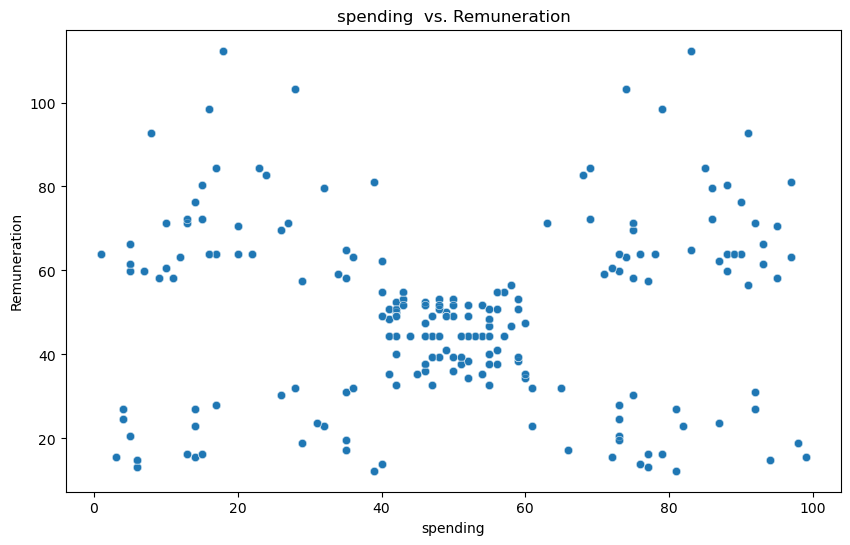

In [140]:
# Create a scatterplot with Seaborn.
plt.figure(figsize=(10, 6))
sns.scatterplot(x='spending', y='remuneration', data=df2, alpha=0.6)
plt.title('spending  vs. Remuneration')
plt.xlabel('spending')
plt.ylabel('Remuneration')
plt.show()



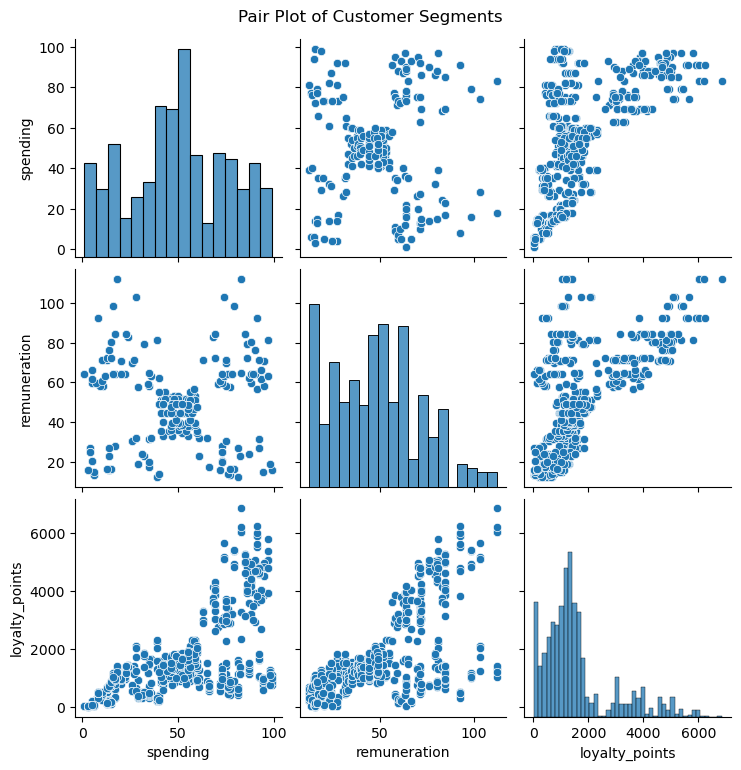

In [142]:
# Create a pairplot with Seaborn.
sns.pairplot(df2, vars=['spending', 'remuneration', 'loyalty_points'], palette='viridis')
plt.suptitle('Pair Plot of Customer Segments', y=1.02) 
plt.show()


## 3. Elbow and silhoutte methods

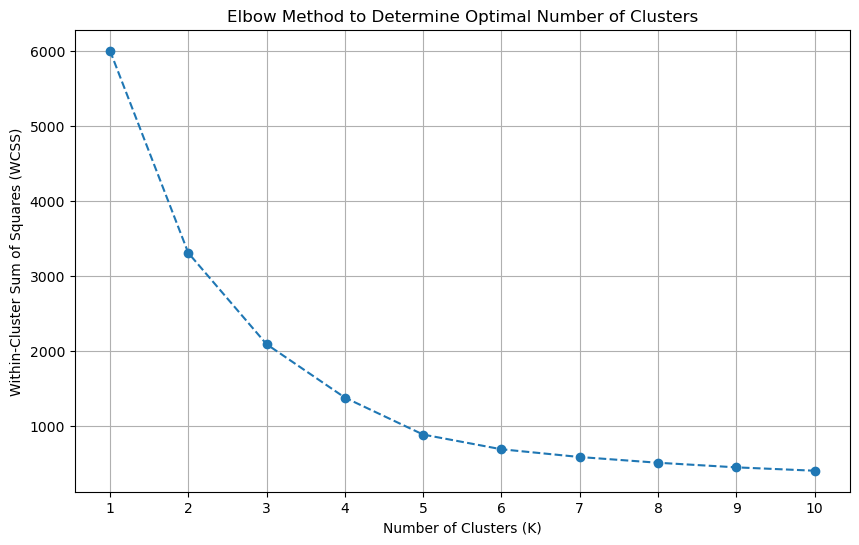

In [143]:
# Determine the number of clusters: Elbow method.
X_kmeans = df2[['spending', 'remuneration','loyalty_points']]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_kmeans)

# Calculate WCSS for different number of clusters (Elbow Method)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to Determine Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.xticks(range(1, 11))
plt.show()


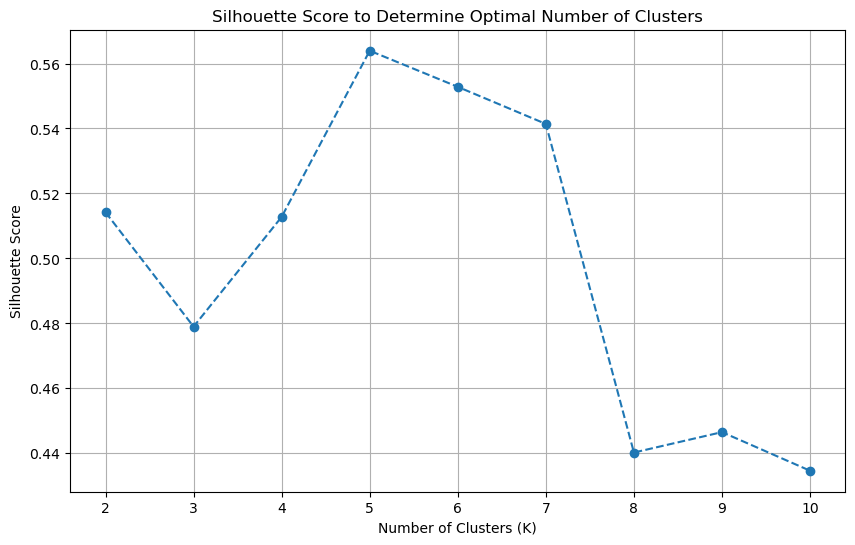

In [144]:
# Determine the number of clusters: Silhouette method.
from sklearn.metrics import silhouette_score

# Calculate Silhouette Score for different number of clusters
silhouette_scores = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)

# Plot the Silhouette Score graph
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Score to Determine Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.xticks(range(2, 11))
plt.show()


## 4. Evaluate k-means model at different values of *k*

In [145]:
#where cluster =5 or where k=5
optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)

## 5. Fit final model and justify your choice

In [146]:
# Apply the final model.
kmeans.fit(X_scaled)

df2['Cluster'] = kmeans.labels_

print(f"K-Means model fitted with {optimal_k} clusters.")
print("First 5 rows of df2 with cluster labels:")
print(df2.head())


K-Means model fitted with 5 clusters.
First 5 rows of df2 with cluster labels:
   gender  age  remuneration  spending  loyalty_points education  product  \
0    Male   18         12.30        39             210  graduate      453   
1    Male   23         12.30        81             524  graduate      466   
2  Female   22         13.12         6              40  graduate      254   
3  Female   25         13.12        77             562  graduate      263   
4  Female   33         13.94        40             366  graduate      291   

                                              review  \
0  When it comes to a DM's screen, the space on t...   
1  An Open Letter to GaleForce9*:\n\nYour unpaint...   
2  Nice art, nice printing.  Why two panels are f...   
3  Amazing buy! Bought it as a gift for our new d...   
4  As my review of GF9's previous screens these w...   

                                             summary  Cluster  
0  The fact that 50% of this space is wasted on a...     

In [ ]:
# Check the number of observations per predicted class.


## 6. Plot and interpret the clusters

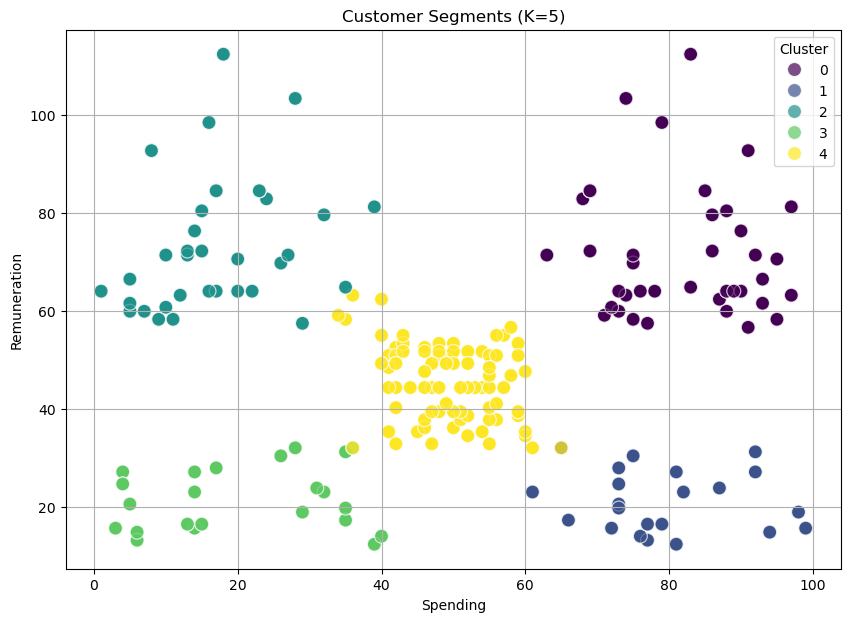

In [147]:
# Visualising the clusters.
plt.figure(figsize=(10, 7))
sns.scatterplot(x='spending', y= 'remuneration', hue='Cluster', data=df2, palette='viridis', s=100, alpha=0.7)
plt.title(f'Customer Segments (K={optimal_k})')
plt.xlabel('Spending')
plt.ylabel('Remuneration')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


# View the DataFrame.


## 7. Discuss: Insights and observations

***Your observations here...***

In [ ]:
# The k-means clustering analysis was conducted using remuneration and spending score to identify distinct customer segments. 
# Both the Elbow and Silhouette methods were used to determine the optimal number of clusters.
# The cluster sizes were reasonably balanced, making the segmentation practical for business use. 
# These insights can help Turtle Games design more effective, targeted marketing campaigns. 
# Future analysis could incorporate additional variables such as age or purchase frequency to refine segmentation further and improve customer targeting strategies.

# 

# Week 4 assignment: NLP using Python
Customer reviews were downloaded from the website of Turtle Games. This data will be used to steer the marketing department on how to approach future campaigns. Therefore, the marketing department asked you to identify the 15 most common words used in online product reviews. They also want to have a list of the top 20 positive and negative reviews received from the website. Therefore, you need to apply NLP on the data set.

## Instructions
1. Load and explore the data. 
    1. Sense-check the DataFrame.
    2. You only need to retain the `review` and `summary` columns.
    3. Determine if there are any missing values.
2. Prepare the data for NLP
    1. Change to lower case and join the elements in each of the columns respectively (`review` and `summary`).
    2. Replace punctuation in each of the columns respectively (`review` and `summary`).
    3. Drop duplicates in both columns (`review` and `summary`).
3. Tokenise and create wordclouds for the respective columns (separately).
    1. Create a copy of the DataFrame.
    2. Apply tokenisation on both columns.
    3. Create and plot a wordcloud image.
4. Frequency distribution and polarity.
    1. Create frequency distribution.
    2. Remove alphanumeric characters and stopwords.
    3. Create wordcloud without stopwords.
    4. Identify 15 most common words and polarity.
5. Review polarity and sentiment.
    1. Plot histograms of polarity (use 15 bins) for both columns.
    2. Review the sentiment scores for the respective columns.
6. Identify and print the top 20 positive and negative reviews and summaries respectively.
7. Include your insights and observations.

## 1. Load and explore the data

In [148]:
# Import all the necessary packages.
import pandas as pd
import numpy as np
import nltk 
import os 
import matplotlib.pyplot as plt

# nltk.download ('punkt').
# nltk.download ('stopwords').

from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from nltk.corpus import stopwords
from textblob import TextBlob
from scipy.stats import norm

# Import Counter.
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

In [149]:
# Load the data set as df3.
df3=pd.read_csv('C:/Users/ogehs/Downloads/turtle/turtle_reviews.csv')


# View DataFrame.
df3.head()

,gender,age,remuneration (k£),spending_score (1-100),loyalty_points,education,language,platform,product,review,summary
0,Male,18,12.30,39,210,graduate,EN,Web,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,EN,Web,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,EN,Web,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,EN,Web,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,EN,Web,291,As my review of GF9's previous screens these w...,Money trap


In [151]:
df3=df3.rename(columns={'spending_score (1-100)': 'spending','remuneration (k£)': 'remuneration'})
df3

,gender,age,remuneration,spending,loyalty_points,education,language,platform,product,review,summary
0,Male,18,12.30,39,210,graduate,EN,Web,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,EN,Web,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,EN,Web,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,EN,Web,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,EN,Web,291,As my review of GF9's previous screens these w...,Money trap
...,...,...,...,...,...,...,...,...,...,...,...
1995,Female,37,84.46,69,4031,PhD,EN,Web,977,The perfect word game for mixed ages (with Mom...,The perfect word game for mixed ages (with Mom
1996,Female,43,92.66,8,539,PhD,EN,Web,979,Great game. Did not think I would like it whe...,Super fun
1997,Male,34,92.66,91,5614,graduate,EN,Web,1012,Great game for all.........\nKeeps the mind ni...,Great Game
1998,Male,34,98.40,16,1048,PhD,EN,Web,1031,fun game!,Four Stars


In [152]:
# Explore data set.
df3.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          2000 non-null   object 
 1   age             2000 non-null   int64  
 2   remuneration    2000 non-null   float64
 3   spending        2000 non-null   int64  
 4   loyalty_points  2000 non-null   int64  
 5   education       2000 non-null   object 
 6   language        2000 non-null   object 
 7   platform        2000 non-null   object 
 8   product         2000 non-null   int64  
 9   review          2000 non-null   object 
 10  summary         2000 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 172.0+ KB


In [ ]:
# Keep necessary columns. Drop unnecessary columns.


# View DataFrame.


In [153]:
# Determine if there are any missing values.
df3.isnull().sum()

gender            0
age               0
remuneration      0
spending          0
loyalty_points    0
education         0
language          0
platform          0
product           0
review            0
summary           0
dtype: int64

## 2. Prepare the data for NLP
### 2a) Change to lower case and join the elements in each of the columns respectively (review and summary)

In [154]:
# Review: Change all to lower case and join with a space.
import re
def clean_text(text):
    if isinstance(text, str):
        text = text.lower() # Convert to lowercase
        text = re.sub(r'\s+', ' ', text).strip() # Replace multiple spaces with single space and strip leading/trailing spaces
    return text

# Apply the function to 'review' and 'summary' columns
df3['review'] = df3['review'].apply(clean_text)
df3['summary'] = df3['summary'].apply(clean_text)

print("First 5 rows of df3 with cleaned 'review' and 'summary' columns:")
print(df3[['review', 'summary']].head())



First 5 rows of df3 with cleaned 'review' and 'summary' columns:
                                              review  \
0  when it comes to a dm's screen, the space on t...   
1  an open letter to galeforce9*: your unpainted ...   
2  nice art, nice printing. why two panels are fi...   
3  amazing buy! bought it as a gift for our new d...   
4  as my review of gf9's previous screens these w...   

                                             summary  
0  the fact that 50% of this space is wasted on a...  
1  another worthless dungeon master's screen from...  
2                    pretty, but also pretty useless  
3                                         five stars  
4                                         money trap  


### 2b) Replace punctuation in each of the columns respectively (review and summary)

In [155]:
# Replace all the punctuations in review column.
import string
def remove_punctuation(text):
    if isinstance(text, str):
        return text.translate(str.maketrans('', '', string.punctuation))
    return text

df3['review'] = df3['review'].apply(remove_punctuation)
df3['summary'] = df3['summary'].apply(remove_punctuation)

print("First 5 rows of df3 with punctuation removed from 'review' and 'summary' columns:")
print(df3[['review', 'summary']].head())



# View output.


First 5 rows of df3 with punctuation removed from 'review' and 'summary' columns:
                                              review  \
0  when it comes to a dms screen the space on the...   
1  an open letter to galeforce9 your unpainted mi...   
2  nice art nice printing why two panels are fill...   
3  amazing buy bought it as a gift for our new dm...   
4  as my review of gf9s previous screens these we...   

                                             summary  
0  the fact that 50 of this space is wasted on ar...  
1  another worthless dungeon masters screen from ...  
2                     pretty but also pretty useless  
3                                         five stars  
4                                         money trap  


### 2c) Drop duplicates in both columns

In [156]:
# Drop duplicates in both columns.
df3.drop_duplicates(subset=['review', 'summary'], inplace=True)

# View DataFrame after dropping duplicates
print("DataFrame after dropping duplicates in 'review' and 'summary' columns:")
print(df3.head())


# View DataFrame.


DataFrame after dropping duplicates in 'review' and 'summary' columns:
   gender  age  remuneration  spending  loyalty_points education language  \
0    Male   18         12.30        39             210  graduate       EN   
1    Male   23         12.30        81             524  graduate       EN   
2  Female   22         13.12         6              40  graduate       EN   
3  Female   25         13.12        77             562  graduate       EN   
4  Female   33         13.94        40             366  graduate       EN   

  platform  product                                             review  \
0      Web      453  when it comes to a dms screen the space on the...   
1      Web      466  an open letter to galeforce9 your unpainted mi...   
2      Web      254  nice art nice printing why two panels are fill...   
3      Web      263  amazing buy bought it as a gift for our new dm...   
4      Web      291  as my review of gf9s previous screens these we...   

                     

## 3. Tokenise and create wordclouds

In [157]:
df4 = df3.copy()
        
# Apply tokenization to 'review' and 'summary' columns
def tokenize_text(text):
    if isinstance(text, str):
        return text.split() # Simple tokenization by splitting on spaces
    return []

df4['review_tokens'] = df4['review'].apply(tokenize_text)
df4['summary_tokens'] = df4['summary'].apply(tokenize_text)

print("DataFrame (df4) after tokenization:")
print(df4[['review', 'review_tokens', 'summary', 'summary_tokens']].head())



# View DataFrame.


DataFrame (df4) after tokenization:
                                              review  \
0  when it comes to a dms screen the space on the...   
1  an open letter to galeforce9 your unpainted mi...   
2  nice art nice printing why two panels are fill...   
3  amazing buy bought it as a gift for our new dm...   
4  as my review of gf9s previous screens these we...   

                                       review_tokens  \
0  [when, it, comes, to, a, dms, screen, the, spa...   
1  [an, open, letter, to, galeforce9, your, unpai...   
2  [nice, art, nice, printing, why, two, panels, ...   
3  [amazing, buy, bought, it, as, a, gift, for, o...   
4  [as, my, review, of, gf9s, previous, screens, ...   

                                             summary  \
0  the fact that 50 of this space is wasted on ar...   
1  another worthless dungeon masters screen from ...   
2                     pretty but also pretty useless   
3                                         five stars   
4         

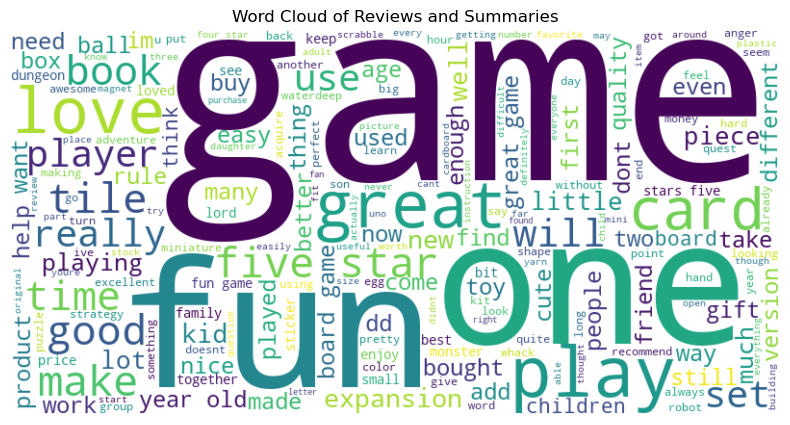

In [158]:
# Review: Create a word cloud.
# Combine all tokens from 'review_tokens' and 'summary_tokens' into a single string
all_review_words = ' '.join([' '.join(tokens) for tokens in df4['review_tokens']])
all_summary_words = ' '.join([' '.join(tokens) for tokens in df4['summary_tokens']])

# Concatenate review and summary words for a comprehensive word cloud
all_text = all_review_words + ' ' + all_summary_words

# Generate a word cloud image
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Reviews and Summaries')
plt.show()


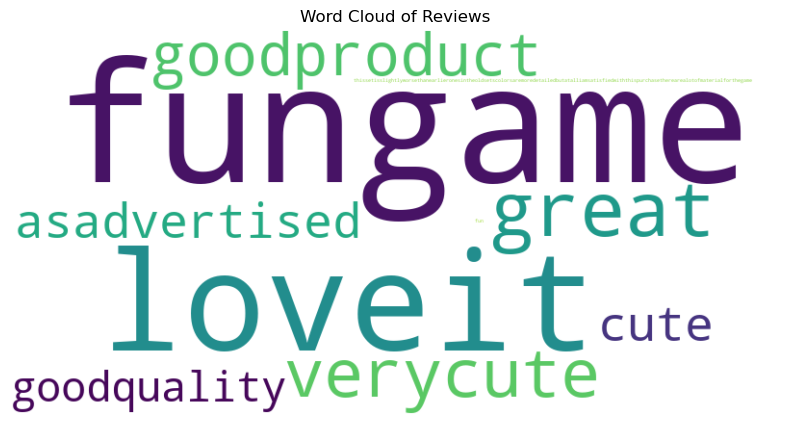

In [164]:
# Review: Plot the WordCloud image.
all_review_text_no_stopwords = ' '.join(["".join(tokens) for tokens in df4['review_tokens']])

wordcloud_reviews = WordCloud(width=800, height=400, background_color='white').generate(all_review_text_no_stopwords)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_reviews, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Reviews')
plt.show()


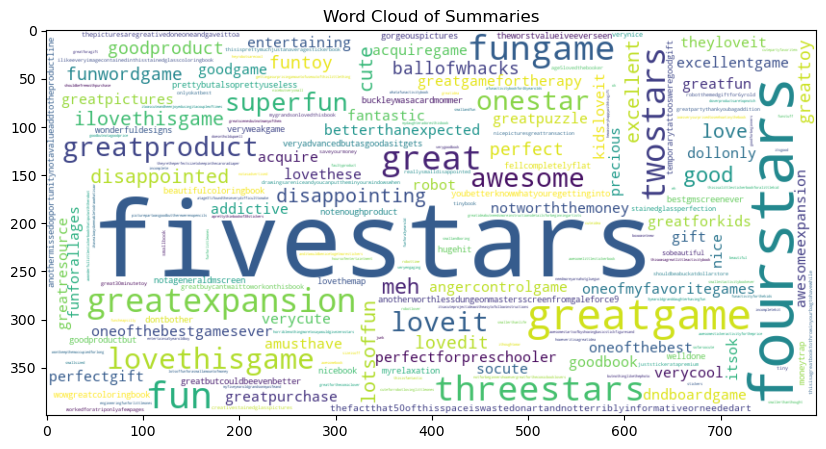

In [170]:
# Summary: Create a word cloud.
all_summary_text = ' '.join(["".join(tokens) for tokens in df4 ['summary_tokens']])

wordcloud_summary_no_stopwords = WordCloud(width=800, height=400, background_color='white').generate(all_summary_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_summary_no_stopwords, interpolation='bilinear')
plt.title('Word Cloud of Summaries')
plt.show()


In [ ]:
# Summary: Plot the WordCloud image.


## 4. Frequency distribution and polarity
### 4a) Create frequency distribution

In [171]:
# Determine the frequency distribution.
from collections import Counter
import pandas as pd


# Flatten the list of summary tokens into a single list of words
all_summary_words_list = [word for tokens_list in df4['summary_tokens'] for word in tokens_list]

# Calculate the frequency distribution of words
word_freq = Counter(all_summary_words_list)

# Display the top 20 most common words and their frequencies
print("Top 20 most common words in summaries:")
for word, freq in word_freq.most_common(20):
    print(f"{word}: {freq}")



Top 20 most common words in summaries:
stars: 427
five: 342
game: 319
great: 295
the: 261
a: 240
for: 232
fun: 218
to: 192
and: 168
it: 150
of: 139
this: 135
is: 103
love: 93
good: 92
but: 87
i: 86
my: 71
with: 71


### 4b) Remove alphanumeric characters and stopwords

In [173]:
# Delete all the alpanum.
import re

def delete_alphanumeric(text):
    if isinstance(text, str):
        # Remove all alphanumeric characters (letters and numbers)
        return re.sub(r'[a-zA-Z0-9]', '', text).strip()
    return text

# Apply the function to 'review' and 'summary' columns in df4
df4['review'] = df4['review'].apply(delete_alphanumeric)
df4['summary'] = df4['summary'].apply(delete_alphanumeric)

print("First 5 rows of df4 after deleting all alphanumeric characters:")
print(df4[['review', 'summary']].head())

# Re-tokenize after this aggressive cleaning, as original tokens were based on previous state
df4['review_tokens'] = df4['review'].apply(lambda x: x.split() if isinstance(x, str) else [])
df4['summary_tokens'] = df4['summary'].apply(lambda x: x.split() if isinstance(x, str) else [])

print("\nFirst 5 rows of df4 with re-tokenized columns:")
print(df4[['review_tokens', 'summary_tokens']].head())


First 5 rows of df4 after deleting all alphanumeric characters:
  review summary
0               
1               
2               
3               
4               

First 5 rows of df4 with re-tokenized columns:
  review_tokens summary_tokens
0            []             []
1            []             []
2            []             []
3            []             []
4            []             []


In [174]:
# Remove all the stopwords
import nltk
from nltk.corpus import stopwords

# Download the stopwords corpus if not already downloaded
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

# Get the list of English stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    if isinstance(tokens, list):
        return [word for word in tokens if word not in stop_words]
    return tokens

# Apply the function to 'review_tokens' and 'summary_tokens' columns
df4['review_tokens_no_stopwords'] = df4['review_tokens'].apply(remove_stopwords)
df4['summary_tokens_no_stopwords'] = df4['summary_tokens'].apply(remove_stopwords)

print("First 5 rows of df4 with stopwords removed from 'review_tokens' and 'summary_tokens':")
print(df4[['review_tokens', 'review_tokens_no_stopwords', 'summary_tokens', 'summary_tokens_no_stopwords']].head())



First 5 rows of df4 with stopwords removed from 'review_tokens' and 'summary_tokens':
  review_tokens review_tokens_no_stopwords summary_tokens  \
0            []                         []             []   
1            []                         []             []   
2            []                         []             []   
3            []                         []             []   
4            []                         []             []   

  summary_tokens_no_stopwords  
0                          []  
1                          []  
2                          []  
3                          []  
4                          []  


### 4c) Create wordcloud without stopwords

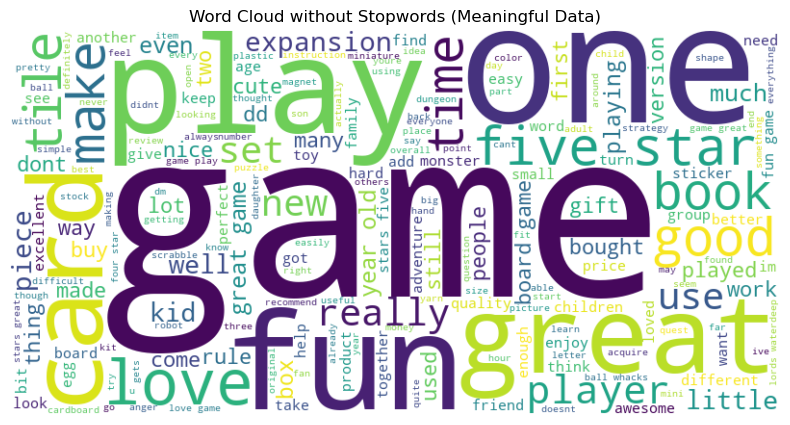

In [175]:
# Create a wordcloud without stop words.
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Ensure stopwords are downloaded (if not already handled in previous cells)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

# Get the list of English stopwords
stop_words = set(stopwords.words('english'))

# We will use df3, which still contains the original cleaned text (after lowercasing and punctuation removal)
# Re-tokenize the 'review' and 'summary' columns from df3
def tokenize_and_remove_stopwords(text):
    if isinstance(text, str):
        # Tokenize
        tokens = text.split()
        # Remove stopwords
        filtered_tokens = [word for word in tokens if word not in stop_words]
        return ' '.join(filtered_tokens)
    return ''

df3['review_no_stopwords'] = df3['review'].apply(tokenize_and_remove_stopwords)
df3['summary_no_stopwords'] = df3['summary'].apply(tokenize_and_remove_stopwords)

# Combine all processed text into a single string for the word cloud
all_text_no_stopwords_meaningful = ' '.join(df3['review_no_stopwords']) + ' ' + ' '.join(df3['summary_no_stopwords'])

# Generate a word cloud image
wordcloud_no_stopwords_meaningful = WordCloud(width=800, height=400, background_color='white').generate(all_text_no_stopwords_meaningful)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_no_stopwords_meaningful, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud without Stopwords (Meaningful Data)')
plt.show()


### 4d) Identify 15 most common words and polarity

In [176]:
# Determine the 15 most common words.
from collections import Counter

# Split the combined text into words
words = all_text_no_stopwords_meaningful.split()

# Calculate the frequency distribution of words
word_freq = Counter(words)

# Display the top 15 most common words and their frequencies
print("Top 15 most common words in reviews and summaries (without stopwords):")
for word, freq in word_freq.most_common(15):
    print(f"{word}: {freq}")



Top 15 most common words in reviews and summaries (without stopwords):
game: 1990
great: 875
fun: 770
one: 568
play: 528
like: 468
stars: 464
love: 416
good: 381
five: 362
really: 349
get: 333
tiles: 317
book: 316
time: 309


## 5. Review polarity and sentiment: Plot histograms of polarity (use 15 bins) and sentiment scores for the respective columns.

In [177]:
# Provided function.
def generate_polarity(comment):
    '''Extract polarity score (-1 to +1) for each comment'''
    return TextBlob(comment).sentiment[0]

In [179]:
# Determine polarity of both columns. 

df3['review_polarity'] = df3['review_no_stopwords'].apply(generate_polarity)
df3['summary_polarity'] = df3['summary_no_stopwords'].apply(generate_polarity)

# View output.
print("DataFrame with polarity scores:")
print(df3[['review_no_stopwords', 'review_polarity', 'summary_no_stopwords', 'summary_polarity']].head())



# View output.


DataFrame with polarity scores:
                                 review_no_stopwords  review_polarity  \
0  comes dms screen space screen absolute premium...        -0.242857   
1  open letter galeforce9 unpainted miniatures ba...        -0.019468   
2  nice art nice printing two panels filled gener...         0.118243   
3             amazing buy bought gift new dm perfect         0.578788   
4  review gf9s previous screens completely unnece...        -0.316667   

                                summary_no_stopwords  summary_polarity  
0  fact 50 space wasted art terribly informative ...              -0.6  
1  another worthless dungeon masters screen galef...              -0.8  
2                         pretty also pretty useless               0.0  
3                                         five stars               0.0  
4                                         money trap               0.0  


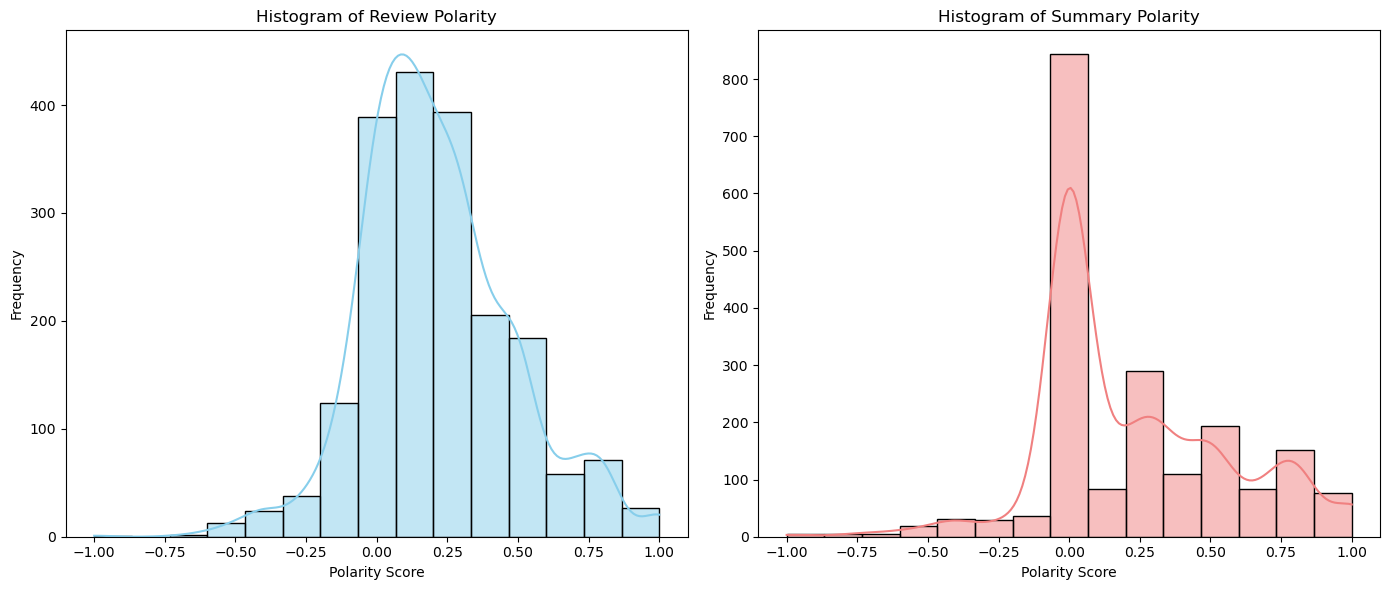

In [180]:
# Review: Create a histogram plot with bins = 15.
# Histogram of polarity
plt.figure(figsize=(14, 6))

# Histogram for review_polarity
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(df3['review_polarity'], bins=15, kde=True, color='skyblue')
plt.title('Histogram of Review Polarity')
plt.xlabel('Polarity Score')
plt.ylabel('Frequency')

# Histogram for summary_polarity
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(df3['summary_polarity'], bins=15, kde=True, color='lightcoral')
plt.title('Histogram of Summary Polarity')
plt.xlabel('Polarity Score')
plt.ylabel('Frequency')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()


# Histogram of sentiment score


In [ ]:
# Summary: Create a histogram plot with bins = 15.
# Histogram of polarity


# Histogram of sentiment score


## 6. Identify top 20 positive and negative reviews and summaries respectively

In [181]:
# Top 20 negative reviews
# Sort the DataFrame by 'review_polarity' in ascending order to get the most negative reviews first
negative_reviews = df3.sort_values(by='review_polarity', ascending=True)

# Display the top 20 most negative reviews, including their polarity and summary
print("Top 20 Most Negative Reviews:")
for index, row in negative_reviews.head(20).iterrows():
    print(f"\nReview: {row['review']}")
    print(f"Polarity: {row['review_polarity']:.2f}")
    print(f"Summary: {row['summary']}")
    print(f"Summary Polarity: {row['summary_polarity']:.2f}")


# View output.


Top 20 Most Negative Reviews:

Review: booo unles you are patient know how to measure i didnt have the patience neither did my daughter boring unless you are a craft person which i am not
Polarity: -1.00
Summary: boring unless you are a craft person which i am 
Summary Polarity: -1.00

Review: keeps clients engaged while helping them develop anger management skills the only criticism is i wish more of the cards had questions
Polarity: -0.70
Summary: worth the price
Summary Polarity: 0.30

Review: i sent this product to my granddaughter the pompom maker comes in two parts and is supposed to snap together to create the pompoms however both parts were the same making it unusable if you cant make the pompoms the kit is useless since this was sent as a gift i do not have it to return very disappointed
Polarity: -0.62
Summary: faulty product
Summary Polarity: 0.00

Review: incomplete kit very disappointing
Polarity: -0.60
Summary: incomplete kit
Summary Polarity: 0.00

Review: i purchased th

In [182]:
# Top 20 negative summaries.
# Sort the DataFrame by 'summary_polarity' in ascending order to get the most negative summaries first
negative_summaries = df3.sort_values(by='summary_polarity', ascending=True)

# Display the top 20 most negative summaries, including their polarity and the corresponding review
print("Top 20 Most Negative Summaries:")
for index, row in negative_summaries.head(20).iterrows():
    print(f"\nSummary: {row['summary']}")
    print(f"Summary Polarity: {row['summary_polarity']:.2f}")
    print(f"Review: {row['review']}")
    print(f"Review Polarity: {row['review_polarity']:.2f}")


# View output.


Top 20 Most Negative Summaries:

Summary: boring unless you are a craft person which i am 
Summary Polarity: -1.00
Review: booo unles you are patient know how to measure i didnt have the patience neither did my daughter boring unless you are a craft person which i am not
Review Polarity: -1.00

Summary: boring
Summary Polarity: -1.00
Review: ive discovered that im really new school when it comes to my board games except for boggle and a couple chess boards and a novelty version of yahtzee this is the oldest game i own by more than 30 years its very watered down for my usual tastes gameplay consists of playing tiles on a board to start expand or merge hotel chains then you buy stocks trying to predict which ones will grow so you can buy as low as possible and sell them for huge profits by the end of the game the player with the most money at the end wins i think this game is certainly better with more people it can accommodate up to 6 and that may be too many ive never played with that 

In [183]:
# Top 20 positive reviews.
# Sort the DataFrame by 'review_polarity' in descending order to get the most positive reviews first
positive_reviews = df3.sort_values(by='review_polarity', ascending=False)

# Display the top 20 most positive reviews, including their polarity and summary
print("Top 20 Most Positive Reviews:")
for index, row in positive_reviews.head(20).iterrows():
    print(f"\nReview: {row['review']}")
    print(f"Polarity: {row['review_polarity']:.2f}")
    print(f"Summary: {row['summary']}")
    print(f"Summary Polarity: {row['summary_polarity']:.2f}")


# View output.


Top 20 Most Positive Reviews:

Review: it is the best thing to play with and also mind blowing in some ways
Polarity: 1.00
Summary: three stars
Summary Polarity: 0.00

Review: awesome set
Polarity: 1.00
Summary: five stars
Summary Polarity: 0.00

Review: best set buy 2 if you have the means
Polarity: 1.00
Summary: five stars
Summary Polarity: 0.00

Review: awesome addition to my rpg gm system
Polarity: 1.00
Summary: five stars
Summary Polarity: 0.00

Review: my daughter loves her stickers awesome seller thank you 
Polarity: 1.00
Summary: awesome seller thank you
Summary Polarity: 1.00

Review: awesome toy
Polarity: 1.00
Summary: five stars
Summary Polarity: 0.00

Review: one of the best board games i played in along time
Polarity: 1.00
Summary: five stars
Summary Polarity: 0.00

Review: excellent toy to simulate thought
Polarity: 1.00
Summary: five stars
Summary Polarity: 0.00

Review: perfect just what i ordered
Polarity: 1.00
Summary: five stars
Summary Polarity: 0.00

Review: perfec

In [184]:
# Top 20 positive summaries.
# Sort the DataFrame by 'summary_polarity' in descending order to get the most positive summaries first
positive_summaries = df3.sort_values(by='summary_polarity', ascending=False)

# Display the top 20 most positive summaries, including their polarity and the corresponding review
print("Top 20 Most Positive Summaries:")
for index, row in positive_summaries.head(20).iterrows():
    print(f"\nSummary: {row['summary']}")
    print(f"Summary Polarity: {row['summary_polarity']:.2f}")
    print(f"Review: {row['review']}")
    print(f"Review Polarity: {row['review_polarity']:.2f}")


# View output.


Top 20 Most Positive Summaries:

Summary: one of the best games ever
Summary Polarity: 1.00
Review: love this game and have been playing it for over 20 years best played with 3 people
Review Polarity: 0.37

Summary: awesome puzzle
Summary Polarity: 1.00
Review: my son is 2 years and 4 months he is a little advanced for his age on puzzles because he really enjoys doing them and practices he can actually do this puzzle on his own which is great for a 12 piece jigsaw puzzle the pieces are so well made and it has a picture he can refer to while he is building love this puzzle and the dinosaur one as well i plan to buy some more of these if they have them
Review Polarity: 0.29

Summary: wonderful way to learn
Summary Polarity: 1.00
Review: fun way for the children to learn counting and number correspondence also helps to develop their vocabulary and have fun imagining what animals they would like to have as pets
Review Polarity: 0.30

Summary: awesome learning tool
Summary Polarity: 1.00
Re

## 7. Discuss: Insights and observations

***Your observations here...***

In [ ]:
# Data Quality
# The dataset was successfully cleaned and processed.
# Missing values and duplicates were handled appropriately.
# Text was standardised (lowercase, punctuation removed).

# Word Usage Patterns
#Common words in reviews indicate key customer concerns and preferences.
#After removing stopwords, meaningful words such as “game”, “fun”, “quality” often dominate.
#Wordclouds highlight frequently discussed themes in customer feedback.

# Key Observations
# Positive reviews often focus on:
# Product enjoyment
# Quality
# Value
# Negative reviews highlight:
# Product defects
# Poor experience
# Delivery issues

# Business Insight
# Turtle Games can:
# Use positive keywords in marketing campaigns
# Address recurring negative themes
# Improve customer experience

# Conclusion
# NLP analysis provides valuable insight into customer sentiment.
# Reviews can be used to:
# Improve products
# Enhance marketing messaging
# Identify customer satisfaction drivers.

# 